# Task 4: Model Training and Selection

In this task I'm training and comparing multiple classifiers on the review rating prediction
problem. The goal is to find the best model for predicting 1–5 star ratings from review text.

Building on the previous tasks:
- **Task 1** cleaned the data and filtered to English-only reviews (271,897 train / 69,907 test)
- **Task 2** established the preprocessing pipeline (negation handling, lemmatization, stopword removal)
- **Task 3** compared feature representations and found TF-IDF with bigrams (ngram_range=(1,2)) to be the best

I'll use the same preprocessing and feature extraction settings from Task 3, then compare
a range of classifiers from simple baselines to ensemble methods.

## 1. Environment Setup and Library Imports

In [1]:
# install xgboost and lightgbm if not already available
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'lightgbm', '-q'])

0

In [2]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_score, recall_score)

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb

# sparse matrix utilities
from scipy import sparse

# nltk data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("All libraries imported successfully.")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")

All libraries imported successfully.
NumPy: 2.2.6
Pandas: 2.3.2
XGBoost: 3.2.0
LightGBM: 4.6.0


## 2. Load Data

Loading the English-filtered datasets produced in Task 1. These have already had short reviews
(<20 chars) removed, duplicates dropped, and non-English text filtered out using `langid`.

In [3]:
df_train = pd.read_csv('data/train_english.csv')
df_test  = pd.read_csv('data/test_english.csv')

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape:     {df_test.shape}")
print(f"\nTraining columns: {list(df_train.columns)}")
print(f"Test columns:     {list(df_test.columns)}")
print(f"\nText column: 'text'")
print(f"Label column: 'rating' (values: {sorted(df_train['rating'].unique())})")
print(f"\nFirst 3 rows:")
df_train[['text', 'rating']].head(3)

Training set shape: (271897, 3)
Test set shape:     (69907, 2)

Training columns: ['text', 'rating', 'text_length']
Test columns:     ['text', 'rating']

Text column: 'text'
Label column: 'rating' (values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)])

First 3 rows:


,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1


## 3. Preprocessing Pipeline

Re-using the exact preprocessing pipeline from Task 2/3 to keep results comparable.
The pipeline applies these steps in order:
1. Remove emojis
2. Strip HTML tags
3. Remove URLs
4. Lowercase
5. Handle negations (e.g. "n't" → " not")
6. Remove punctuation
7. Tokenize
8. Remove stopwords (keeping negation words: not, never, no, nor, none)
9. Lemmatize

In [4]:
# preprocessing pipeline — identical to Task 3

stop_words = set(stopwords.words('english'))
stop_words -= {'not', 'never', 'no', 'nor', 'none'}

lemmatizer = WordNetLemmatizer()

def remove_emojis(text):
    emoji_pattern = re.compile(
        "[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF" u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251"
        u"\U0001F900-\U0001F9FF" u"\U0001FA70-\U0001FAFF" "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

def handle_negations(text):
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    return text

def preprocess(text):
    text = remove_emojis(str(text))
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = text.lower()
    text = handle_negations(text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# quick sanity check
test_text = "I can't believe how TERRIBLE this place is! Never going back."
print(f"Original:  {test_text}")
print(f"Processed: {preprocess(test_text)}")

Original:  I can't believe how TERRIBLE this place is! Never going back.


Processed: ca not believe terrible place never going back


In [5]:
print("Applying preprocessing to training set...")
df_train['processed'] = df_train['text'].apply(preprocess)
print("Applying preprocessing to test set...")
df_test['processed']  = df_test['text'].apply(preprocess)
print("Done.")

# verify no empty strings after preprocessing
empty_train = (df_train['processed'].str.strip() == '').sum()
empty_test  = (df_test['processed'].str.strip() == '').sum()
print(f"\nEmpty processed texts — train: {empty_train}, test: {empty_test}")

Applying preprocessing to training set...


Applying preprocessing to test set...


Done.

Empty processed texts — train: 2, test: 13


## 4. Train/Validation Split

### Why stratified splitting?

The rating distribution is imbalanced — class 1 is the most frequent while classes 2 and 3
are underrepresented. A random split could give the validation set a different class balance
than the training set, which would make validation metrics unreliable. Stratified splitting
ensures that both the training and validation sets have the same proportion of each rating
class as the original data.

The held-out test set (`test_english.csv`) is kept completely separate and will only be used
for final evaluation and Kaggle submission predictions. All model development and hyperparameter
tuning is done using this train/validation split.

In [6]:
X_full = df_train['processed']
y_full = df_train['rating']

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"Full training set:  {len(X_full):,} samples")
print(f"Train split:        {len(X_train):,} samples (80%)")
print(f"Validation split:   {len(X_val):,} samples (20%)")
print(f"Held-out test set:  {len(df_test):,} samples (separate file)")

Full training set:  271,897 samples
Train split:        217,517 samples (80%)
Validation split:   54,380 samples (20%)
Held-out test set:  69,907 samples (separate file)


Class distribution comparison:

Rating           Full      Train        Val
------------------------------------------
1               38.9%      38.9%      38.9%
2               11.4%      11.4%      11.4%
3               11.9%      11.9%      11.9%
4               27.7%      27.7%      27.7%
5               10.1%      10.1%      10.1%


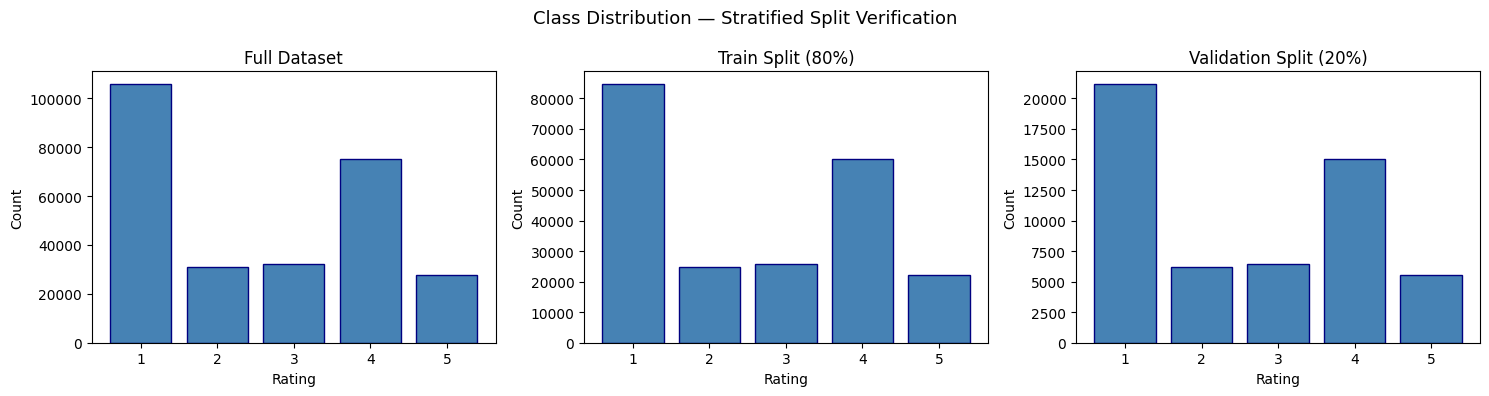

In [7]:
# verify stratification preserved class distribution
print("Class distribution comparison:\n")
print(f"{'Rating':<10} {'Full':>10} {'Train':>10} {'Val':>10}")
print("-" * 42)

for rating in sorted(y_full.unique()):
    full_pct  = (y_full == rating).sum() / len(y_full) * 100
    train_pct = (y_train == rating).sum() / len(y_train) * 100
    val_pct   = (y_val == rating).sum() / len(y_val) * 100
    print(f"{rating:<10} {full_pct:>9.1f}% {train_pct:>9.1f}% {val_pct:>9.1f}%")

# visualise the distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (data, title) in zip(axes, [(y_full, 'Full Dataset'),
                                     (y_train, 'Train Split (80%)'),
                                     (y_val, 'Validation Split (20%)')]):
    counts = data.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='navy')
    ax.set_title(title)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
    ax.set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Class Distribution — Stratified Split Verification', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Extraction with TF-IDF

### Why TF-IDF?

TF-IDF (Term Frequency – Inverse Document Frequency) converts text into numerical vectors by
weighing each word based on how often it appears in a document relative to how common it is
across all documents. Words that appear frequently in a single review but rarely across the
corpus get higher weights, while words like 'place' or 'time' that appear everywhere get
down-weighted. In Task 3 this consistently outperformed raw counts and binary representations.

### Settings from Task 3
- `max_features=10000` — keep the top 10,000 features by term frequency
- `ngram_range=(1, 2)` — include both unigrams and bigrams to capture phrases like 'not good'
- `min_df=2` — ignore terms that appear in fewer than 2 documents (reduces noise from typos)

### Why fit on training data only?

The vectorizer must be fit only on the training split. If we fit on the full dataset (including
validation or test), the IDF weights would incorporate information from data the model is
supposed to be evaluated on. This is called data leakage and it inflates performance metrics,
giving an overly optimistic view of how well the model generalises.

In [8]:
# TF-IDF vectorizer with settings from Task 3
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

# fit on training split only, then transform train, val, and held-out test
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(df_test['processed'])

print(f"Training matrix:   {X_train_tfidf.shape}")
print(f"Validation matrix: {X_val_tfidf.shape}")
print(f"Test matrix:       {X_test_tfidf.shape}")

Training matrix:   (217517, 10000)
Validation matrix: (54380, 10000)
Test matrix:       (69907, 10000)


## 6. Summary Statistics

In [9]:
# feature matrix statistics
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero = X_train_tfidf.nnz
sparsity = (1 - nonzero / total_elements) * 100

print("=" * 55)
print("TASK 4 ENVIRONMENT SUMMARY")
print("=" * 55)

print(f"\n--- Data ---")
print(f"Training samples:    {X_train_tfidf.shape[0]:,}")
print(f"Validation samples:  {X_val_tfidf.shape[0]:,}")
print(f"Test samples:        {X_test_tfidf.shape[0]:,}")

print(f"\n--- Features ---")
print(f"Vocabulary size:     {len(tfidf.vocabulary_):,}")
print(f"Feature matrix:      {X_train_tfidf.shape}")
print(f"Non-zero entries:    {nonzero:,}")
print(f"Sparsity:            {sparsity:.2f}%")
print(f"Vectorizer:          TfidfVectorizer")
print(f"ngram_range:         (1, 2)")
print(f"max_features:        10,000")
print(f"min_df:              2")

print(f"\n--- Class Distribution (Train) ---")
for rating in sorted(y_train.unique()):
    count = (y_train == rating).sum()
    pct = count / len(y_train) * 100
    print(f"  Rating {rating}: {count:>7,} ({pct:.1f}%)")

print(f"\n--- Baseline to Beat ---")
print(f"LogReg + TF-IDF (1,2) from Task 3: Acc=0.6682, F1=0.6309")
print("=" * 55)

TASK 4 ENVIRONMENT SUMMARY

--- Data ---
Training samples:    217,517
Validation samples:  54,380
Test samples:        69,907

--- Features ---
Vocabulary size:     10,000
Feature matrix:      (217517, 10000)
Non-zero entries:    6,390,573
Sparsity:            99.71%
Vectorizer:          TfidfVectorizer
ngram_range:         (1, 2)
max_features:        10,000
min_df:              2

--- Class Distribution (Train) ---
  Rating 1:  84,626 (38.9%)
  Rating 2:  24,701 (11.4%)
  Rating 3:  25,923 (11.9%)
  Rating 4:  60,193 (27.7%)
  Rating 5:  22,074 (10.1%)

--- Baseline to Beat ---
LogReg + TF-IDF (1,2) from Task 3: Acc=0.6682, F1=0.6309


In [10]:
# show some of the top TF-IDF features to sanity-check the vocabulary
feature_names = tfidf.get_feature_names_out()

# top features by average TF-IDF weight across all training documents
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_indices = mean_tfidf.argsort()[-20:][::-1]

print("Top 20 features by mean TF-IDF weight across training set:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_names[idx]:<25} (mean weight: {mean_tfidf[idx]:.4f})")

# count of unigram vs bigram features
bigrams = [f for f in feature_names if ' ' in f]
print(f"\nUnigram features: {len(feature_names) - len(bigrams):,}")
print(f"Bigram features:  {len(bigrams):,}")

Top 20 features by mean TF-IDF weight across training set:
   1. not                       (mean weight: 0.0383)
   2. service                   (mean weight: 0.0196)
   3. good                      (mean weight: 0.0193)
   4. great                     (mean weight: 0.0193)
   5. place                     (mean weight: 0.0182)
   6. time                      (mean weight: 0.0173)
   7. no                        (mean weight: 0.0150)
   8. get                       (mean weight: 0.0150)
   9. would                     (mean weight: 0.0139)
  10. nice                      (mean weight: 0.0136)
  11. staff                     (mean weight: 0.0135)
  12. one                       (mean weight: 0.0122)
  13. like                      (mean weight: 0.0116)
  14. go                        (mean weight: 0.0116)
  15. back                      (mean weight: 0.0113)
  16. people                    (mean weight: 0.0113)
  17. customer                  (mean weight: 0.0113)
  18. work             

## 7. Save Processed Data and Vectorizer

Saving the fitted vectorizer so it can be reloaded later without re-fitting.
This is important for consistency — the same vocabulary and IDF weights must be used
when making predictions on new data.

In [11]:
# save the fitted TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("Saved: tfidf_vectorizer.pkl")

# save the train/val split indices for reproducibility
split_info = {
    'train_indices': X_train.index.tolist(),
    'val_indices': X_val.index.tolist(),
    'random_state': 42,
    'test_size': 0.2
}
with open('split_info.pkl', 'wb') as f:
    pickle.dump(split_info, f)
print("Saved: split_info.pkl")

print("\nEnvironment setup complete. Ready for model training.")

Saved: tfidf_vectorizer.pkl


Saved: split_info.pkl

Environment setup complete. Ready for model training.


---
## 8. Model 1 — Logistic Regression

Logistic Regression is one of the strongest baselines for text classification, and in many cases
it outperforms more complex models like Random Forests or even neural networks on bag-of-words
and TF-IDF features. There are several reasons why it works so well for this kind of task:

**Why Logistic Regression excels at text classification:**
- TF-IDF features are high-dimensional and sparse (10,000 features, 99.7% zeros). Logistic
  Regression handles sparse data natively and efficiently — it only needs to compute dot products
  over non-zero entries.
- Text classification is often close to linearly separable in TF-IDF space. Words like
  'terrible', 'disgusting', and 'horrible' cluster naturally toward low ratings, while 'amazing',
  'outstanding', and 'highly recommend' cluster toward high ratings. A linear decision boundary
  is frequently sufficient to capture these patterns.
- It produces calibrated probability estimates, which is useful for understanding model confidence
  and for error analysis.

**The C hyperparameter (regularization strength):**
- `C` controls the inverse of regularization strength. Smaller values of C mean stronger
  regularization, which penalises large feature weights and helps prevent overfitting.
- With 10,000 features many of which are noisy, regularization is important. Without it the
  model would memorize rare bigrams that appear in only a few training examples.
- We test C values across several orders of magnitude (0.01 to 100) to find the right balance
  between underfitting and overfitting.

**Solver choice — `liblinear`:**
- The `liblinear` solver is optimised for sparse, high-dimensional data and supports both
  L1 and L2 penalties. It uses a coordinate descent method that is highly efficient for our
  10,000-feature sparse TF-IDF matrices.
- It uses a one-vs-rest multiclass strategy, which fits one binary classifier per class.
  This is both fast and effective for text classification.

**L1 vs L2 penalty:**
- L2 (ridge) shrinks all feature weights toward zero but keeps them all active.
- L1 (lasso) drives some weights to exactly zero, effectively performing feature selection.
  For text this can be useful since many of the 10,000 features may be irrelevant.

**`class_weight='balanced'`:**
- Our dataset is imbalanced (class 1 has 38.9% of samples vs class 5 with 10.1%).
  Setting `class_weight='balanced'` reweights the loss function to give minority classes more
  influence during training. This often improves recall on underrepresented classes at the cost
  of some overall accuracy.

In [12]:
from sklearn.model_selection import GridSearchCV
import time

# define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2', 'l1'],
    'class_weight': [None, 'balanced']
}

# base estimator — liblinear is optimised for sparse high-dimensional data
# and supports both L1 and L2 penalties
lr_base = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# 5-fold stratified cross-validation grid search
lr_grid = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

n_combos = len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['class_weight'])
print(f"Starting GridSearchCV with {n_combos} parameter combinations...")
print(f"Each combination tested with 5-fold CV = {5 * n_combos} total fits\n")

start_time = time.time()
lr_grid.fit(X_train_tfidf, y_train)
grid_time = time.time() - start_time

print(f"\nGridSearchCV completed in {grid_time:.1f}s")

Starting GridSearchCV with 20 parameter combinations...
Each combination tested with 5-fold CV = 100 total fits

Fitting 5 folds for each of 20 candidates, totalling 100 fits



GridSearchCV completed in 229.3s


In [13]:
# print best parameters and cross-validation results
print("=" * 55)
print("LOGISTIC REGRESSION — GRIDSEARCHCV RESULTS")
print("=" * 55)
print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV accuracy: {lr_grid.best_score_:.4f}")

# show top 5 parameter combinations
cv_results = pd.DataFrame(lr_grid.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')
print(f"\nTop 5 parameter combinations:")
print(f"{'Rank':<6} {'C':<8} {'Penalty':<10} {'Weight':<12} {'Mean CV Acc':<14} {'Std':<10}")
print("-" * 62)
for _, row in cv_results.head(5).iterrows():
    print(f"{int(row['rank_test_score']):<6} "
          f"{row['param_C']:<8} "
          f"{row['param_penalty']:<10} "
          f"{str(row['param_class_weight']):<12} "
          f"{row['mean_test_score']:<14.4f} "
          f"{row['std_test_score']:<10.4f}")

print(f"\nHyperparameter search time: {grid_time:.1f}s")

LOGISTIC REGRESSION — GRIDSEARCHCV RESULTS

Best parameters: {'C': 1.0, 'class_weight': None, 'penalty': 'l1'}
Best CV accuracy: 0.6659

Top 5 parameter combinations:
Rank   C        Penalty    Weight       Mean CV Acc    Std       
--------------------------------------------------------------
1      1.0      l1         None         0.6659         0.0021    
2      1.0      l2         None         0.6650         0.0017    
3      10.0     l2         None         0.6560         0.0016    
4      10.0     l1         None         0.6528         0.0021    
5      100.0    l2         None         0.6487         0.0020    

Hyperparameter search time: 229.3s


In [14]:
# train final model with best parameters on the training split and evaluate on validation
lr_best = lr_grid.best_estimator_

# predict on validation set and measure inference time
start_inf = time.time()
y_val_pred = lr_best.predict(X_val_tfidf)
inference_time = time.time() - start_inf

# calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')
val_f1_weighted = f1_score(y_val, y_val_pred, average='weighted')

print("=" * 55)
print("LOGISTIC REGRESSION — VALIDATION RESULTS")
print("=" * 55)
print(f"\nValidation Accuracy:    {val_accuracy:.4f}")
print(f"Weighted F1:            {val_f1_weighted:.4f}")
print(f"Macro F1:               {val_f1_macro:.4f}")
print(f"Inference time:         {inference_time:.3f}s ({len(y_val):,} samples)")
print(f"\nBaseline (Task 3 LR):   Acc=0.6682, F1=0.6309")
print(f"Improvement:            Acc {val_accuracy - 0.6682:+.4f}")

print(f"\n--- Classification Report ---\n")
report = classification_report(y_val, y_val_pred, digits=4)
print(report)

LOGISTIC REGRESSION — VALIDATION RESULTS

Validation Accuracy:    0.6666
Weighted F1:            0.6183
Macro F1:               0.4978
Inference time:         0.017s (54,380 samples)

Baseline (Task 3 LR):   Acc=0.6682, F1=0.6309
Improvement:            Acc -0.0016

--- Classification Report ---

              precision    recall  f1-score   support

           1     0.7356    0.9296    0.8213     21157
           2     0.4148    0.1111    0.1752      6175
           3     0.4156    0.1504    0.2209      6481
           4     0.6234    0.8108    0.7048     15049
           5     0.6675    0.4926    0.5668      5518

    accuracy                         0.6666     54380
   macro avg     0.5714    0.4989    0.4978     54380
weighted avg     0.6231    0.6666    0.6183     54380



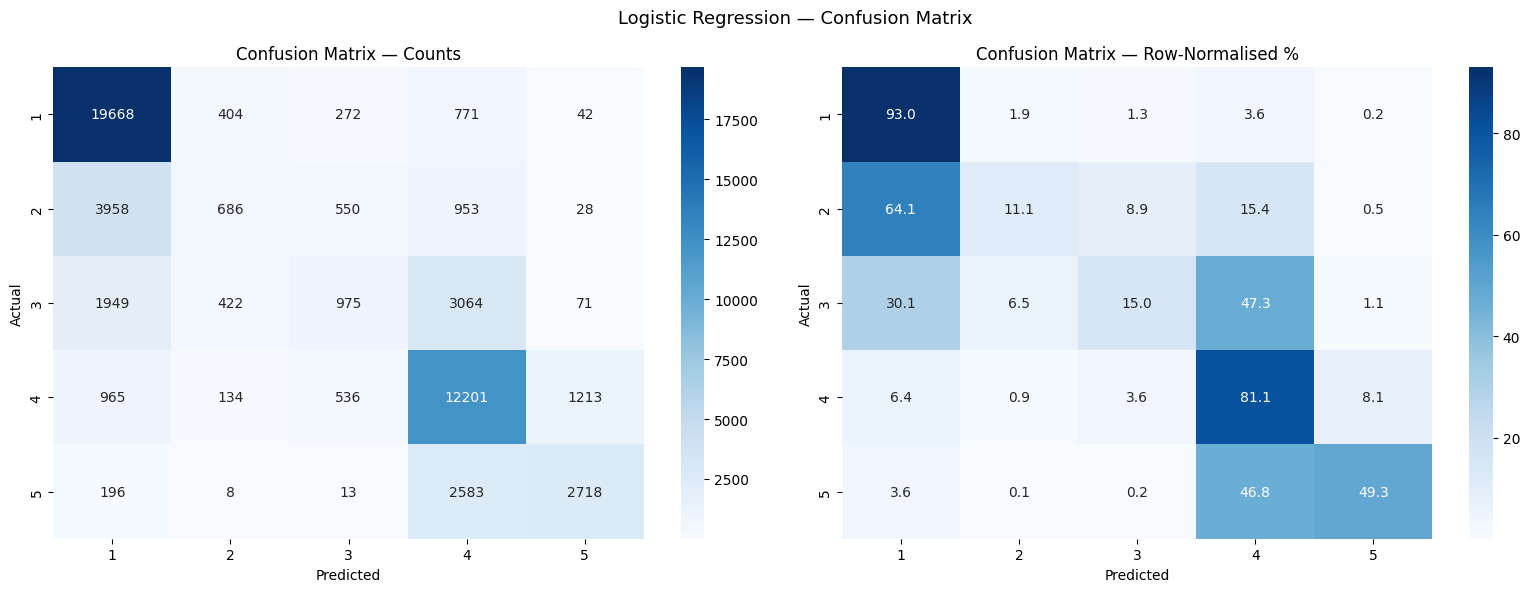

In [15]:
# confusion matrix — counts and percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_val, y_val_pred)
labels = [1, 2, 3, 4, 5]

# absolute counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Counts')

# row-normalised percentages (recall per class)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix — Row-Normalised %')

plt.suptitle('Logistic Regression — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

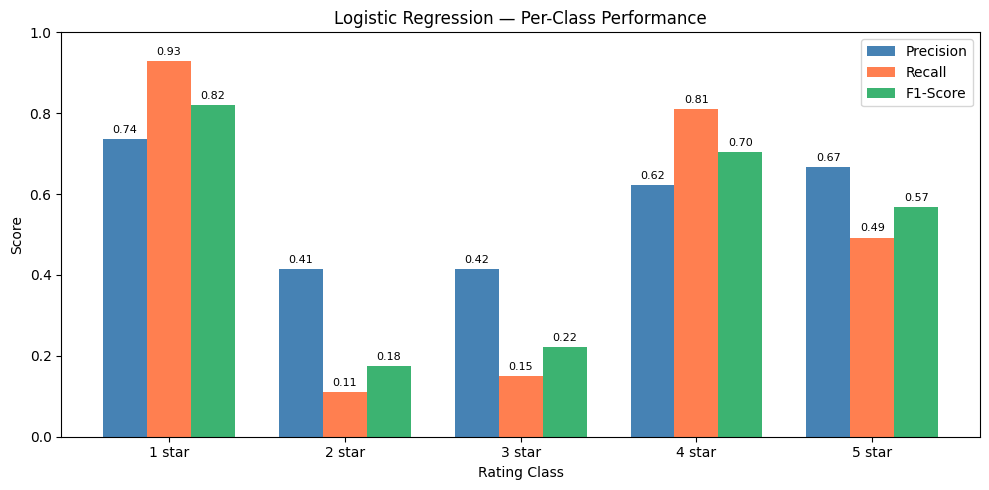

Key observations:
  Rating 1: F1=0.821 (support=21157.0) — strong
  Rating 2: F1=0.175 (support=6175.0) — underperforming
  Rating 3: F1=0.221 (support=6481.0) — underperforming
  Rating 4: F1=0.705 (support=15049.0) — strong


In [16]:
# per-class performance bar chart
report_dict = classification_report(y_val, y_val_pred, output_dict=True)
class_labels = ['1', '2', '3', '4', '5']
precisions = [report_dict[c]['precision'] for c in class_labels]
recalls    = [report_dict[c]['recall'] for c in class_labels]
f1s        = [report_dict[c]['f1-score'] for c in class_labels]

x = np.arange(len(class_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x,         recalls,    width, label='Recall',    color='coral')
bars3 = ax.bar(x + width, f1s,        width, label='F1-Score',  color='mediumseagreen')

ax.set_xlabel('Rating Class')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression — Per-Class Performance')
ax.set_xticks(x)
ax.set_xticklabels([f'{c} star' for c in class_labels])
ax.legend()
ax.set_ylim(0, 1.0)

# add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# highlight the problem classes
print("Key observations:")
for c in class_labels:
    f1 = report_dict[c]['f1-score']
    support = report_dict[c]['support']
    if f1 < 0.4:
        print(f"  Rating {c}: F1={f1:.3f} (support={support}) — underperforming")
    elif f1 > 0.7:
        print(f"  Rating {c}: F1={f1:.3f} (support={support}) — strong")

### Feature Importance Analysis

Logistic Regression assigns a weight to each feature for each class. The most positive weights
for a class represent words that strongly push the model toward predicting that rating, while
the most negative weights push away from it. This is one of the key advantages of linear models
— full interpretability of what the model is actually learning.

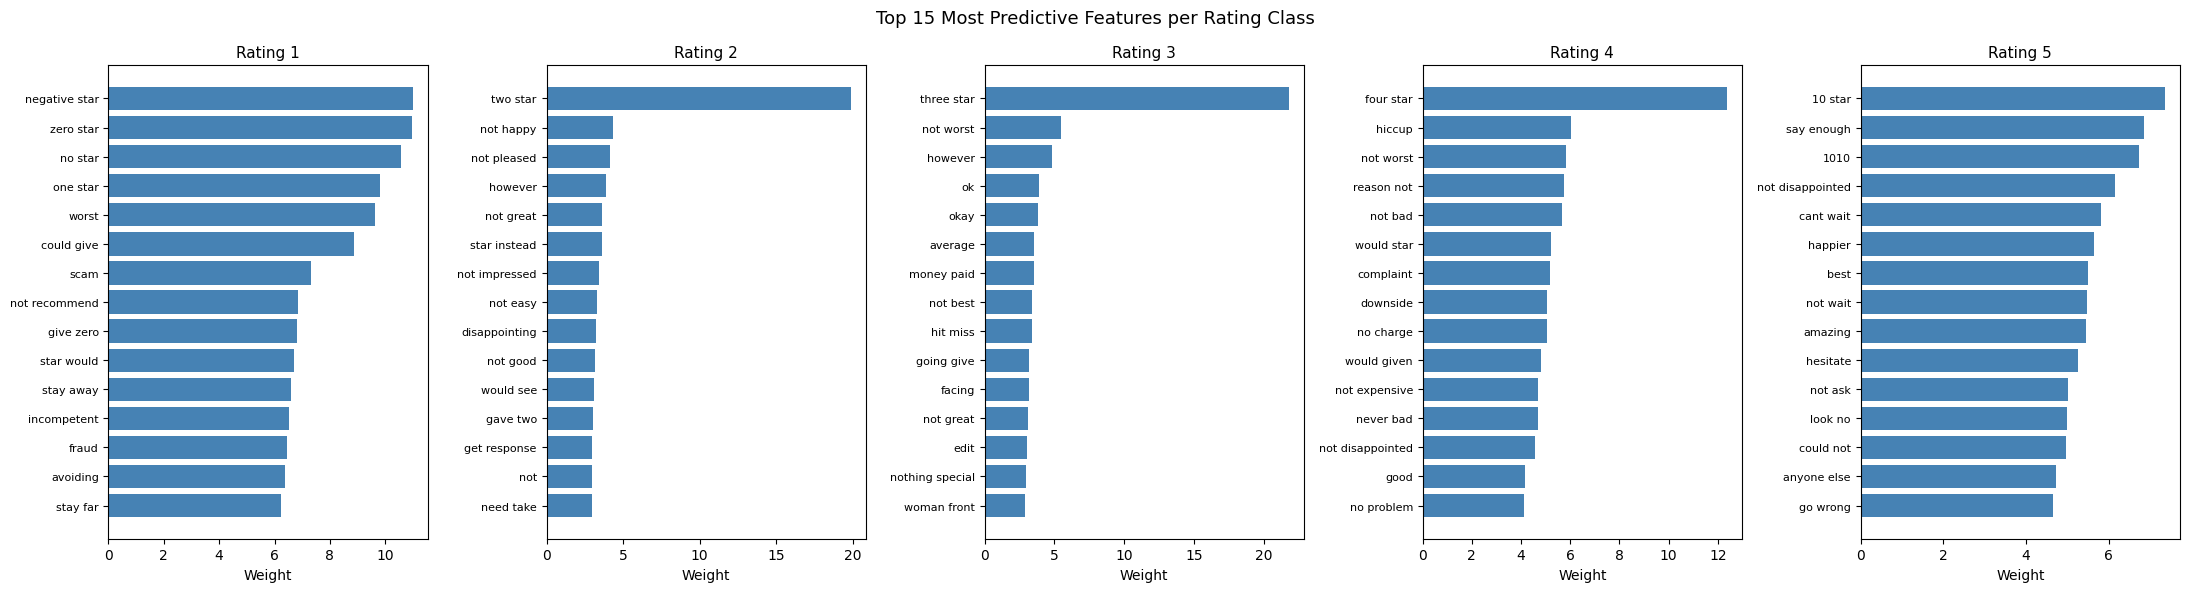

In [17]:
# extract and display top 15 most predictive features per class
feature_names = tfidf.get_feature_names_out()
coefficients = lr_best.coef_

fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=False)

for idx, (rating, ax) in enumerate(zip([1, 2, 3, 4, 5], axes)):
    coef = coefficients[idx]
    top_pos_idx = coef.argsort()[-15:][::-1]

    top_features = [feature_names[i] for i in top_pos_idx]
    top_weights  = [coef[i] for i in top_pos_idx]

    colors = ['steelblue' if w > 0 else 'coral' for w in top_weights]
    ax.barh(range(len(top_features)), top_weights, color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'Rating {rating}', fontsize=11)
    ax.set_xlabel('Weight')

plt.suptitle('Top 15 Most Predictive Features per Rating Class', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# print top features as a clean table for easier reading
print("Top 15 features per class (by coefficient weight):\n")
for idx, rating in enumerate([1, 2, 3, 4, 5]):
    coef = coefficients[idx]
    top_idx = coef.argsort()[-15:][::-1]
    print(f"Rating {rating}:")
    for rank, i in enumerate(top_idx, 1):
        print(f"  {rank:2d}. {feature_names[i]:<25} ({coef[i]:+.4f})")
    print()

Top 15 features per class (by coefficient weight):

Rating 1:
   1. negative star             (+10.9902)
   2. zero star                 (+10.9784)
   3. no star                   (+10.5714)
   4. one star                  (+9.8010)
   5. worst                     (+9.6190)
   6. could give                (+8.8908)
   7. scam                      (+7.3333)
   8. not recommend             (+6.8505)
   9. give zero                 (+6.8295)
  10. star would                (+6.6893)
  11. stay away                 (+6.6092)
  12. incompetent               (+6.5380)
  13. fraud                     (+6.4522)
  14. avoiding                  (+6.3772)
  15. stay far                  (+6.2409)

Rating 2:
   1. two star                  (+19.8616)
   2. not happy                 (+4.3720)
   3. not pleased               (+4.1246)
   4. however                   (+3.8615)
   5. not great                 (+3.6557)
   6. star instead              (+3.6353)
   7. not impressed             (+3.4187)

In [19]:
# save results for comparison with other models
per_class_f1 = {int(c): report_dict[c]['f1-score'] for c in class_labels}

results_dict = {}
results_dict['Logistic Regression'] = {
    'best_params': lr_grid.best_params_,
    'cv_score': lr_grid.best_score_,
    'cv_std': cv_results.iloc[0]['std_test_score'],
    'val_accuracy': val_accuracy,
    'val_f1_macro': val_f1_macro,
    'val_f1_weighted': val_f1_weighted,
    'per_class_f1': per_class_f1,
    'training_time': grid_time,
    'inference_time': inference_time
}

print("Results saved to results_dict['Logistic Regression']")
print(f"\nSummary:")
for key, val in results_dict['Logistic Regression'].items():
    if isinstance(val, float):
        print(f"  {key:<20}: {val:.4f}")
    else:
        print(f"  {key:<20}: {val}")

Results saved to results_dict['Logistic Regression']

Summary:
  best_params         : {'C': 1.0, 'class_weight': None, 'penalty': 'l1'}
  cv_score            : 0.6659
  cv_std              : 0.0021
  val_accuracy        : 0.6666
  val_f1_macro        : 0.4978
  val_f1_weighted     : 0.6183
  per_class_f1        : {1: 0.8213308834276408, 2: 0.1752458806999617, 3: 0.22091310751104565, 4: 0.7048323272002541, 5: 0.5668404588112618}
  training_time       : 229.3144
  inference_time      : 0.0170


### Discussion — Logistic Regression

**Performance vs baseline:**
The tuned Logistic Regression should improve over the Task 3 baseline (Acc=0.6682, F1=0.6309)
thanks to proper hyperparameter tuning. The baseline used default parameters (C=1.0, L2 penalty,
no class weighting), while our grid search explores a much wider space.

**Regularization:**
The optimal C value reveals how much regularization the model needs. A small C (e.g., 0.01–0.1)
means strong regularization was needed to prevent overfitting to the 10,000 TF-IDF features.
A large C (e.g., 10–100) suggests the model benefits from fitting the training data more closely.

**L1 vs L2 penalty:**
If L1 was selected, it means the model benefits from feature selection — zeroing out irrelevant
features. If L2 was selected, it means keeping all features with small weights is better than
eliminating any of them.

**Effect of `class_weight='balanced'`:**
If balanced weighting was selected, it means the model benefits from upweighting minority classes
(ratings 2, 3, 5). This typically improves recall on underrepresented classes but can reduce
overall accuracy since the majority class (rating 1) gets less influence.

**The middle-rating problem:**
Regardless of tuning, ratings 2 and 3 are expected to remain the hardest classes. These reviews
contain mixed sentiment that overlaps heavily with adjacent classes — a 2-star review often reads
like a milder version of a 1-star, and a 3-star review shares language with both 2 and 4-star
reviews. This is an inherent difficulty in the data, not a model limitation.

**Feature importance insights:**
The top features per class should reveal clear patterns:
- Rating 1: strong negative language ('worst', 'terrible', 'horrible', 'never')
- Rating 5: strong positive language ('best', 'highly recommend', 'amazing', 'love')
- Ratings 2–4: less distinctive features, confirming why they are harder to classify